#### <span style="color:cyan">**Imports**</span>

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *

from preprocessing.pipelines import build_pca_pipeline

#### <span style="color:cyan">**Data Preprocessing**</span>

Feature table (abs):
              pc_0      pc_1      pc_2      pc_3      pc_4  ...      pc_7  \
run_id                                                      ...             
run_0001 -1.680643 -2.399366  2.486905 -0.814957  0.306960  ...  0.615309   
run_0002  0.027752 -2.887159  0.398014  1.058010  0.381236  ... -0.096272   
run_0003 -2.105300  2.453100 -2.023367  0.772406  0.335776  ...  0.036559   
run_0004  3.650154  3.792021  2.861437  0.164247  1.360118  ...  0.521677   
run_0005  1.511727 -0.632767 -2.028577 -0.491279 -1.981990  ... -0.289584   

              pc_8      pc_9     pc_10     pc_11  
run_id                                            
run_0001  0.620361  0.128730 -0.145785 -0.242712  
run_0002 -0.027216 -0.479756  0.114388  0.141687  
run_0003  0.450074  0.101287 -0.123741 -0.068608  
run_0004  0.359057  0.639225  0.582929  0.393250  
run_0005  0.601928  0.649958  0.262297 -0.562669  

[5 rows x 12 columns]



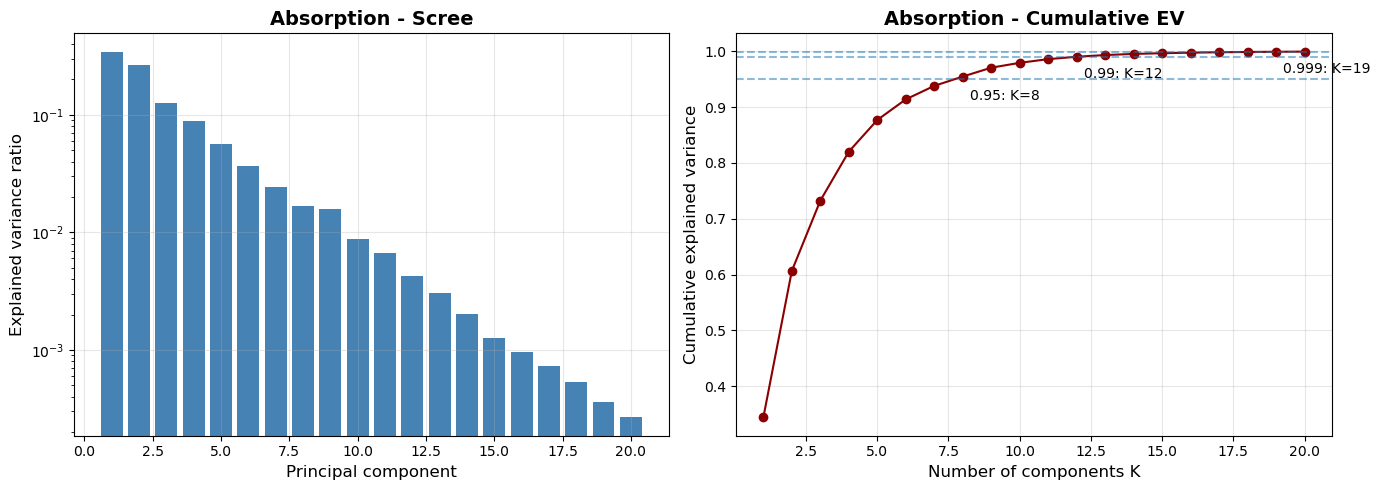

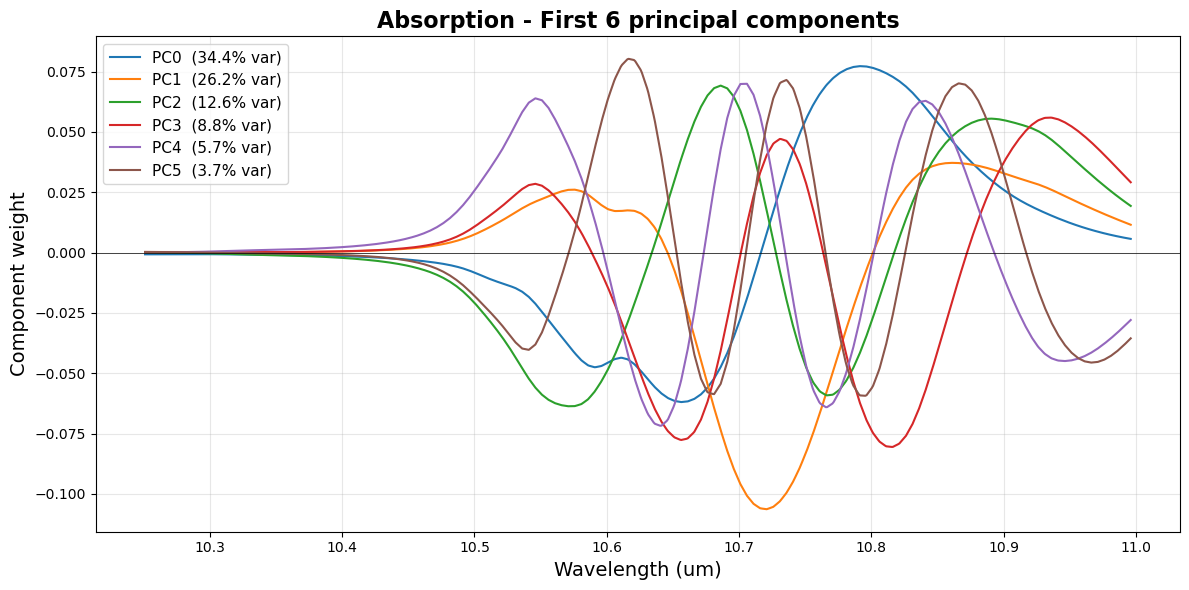

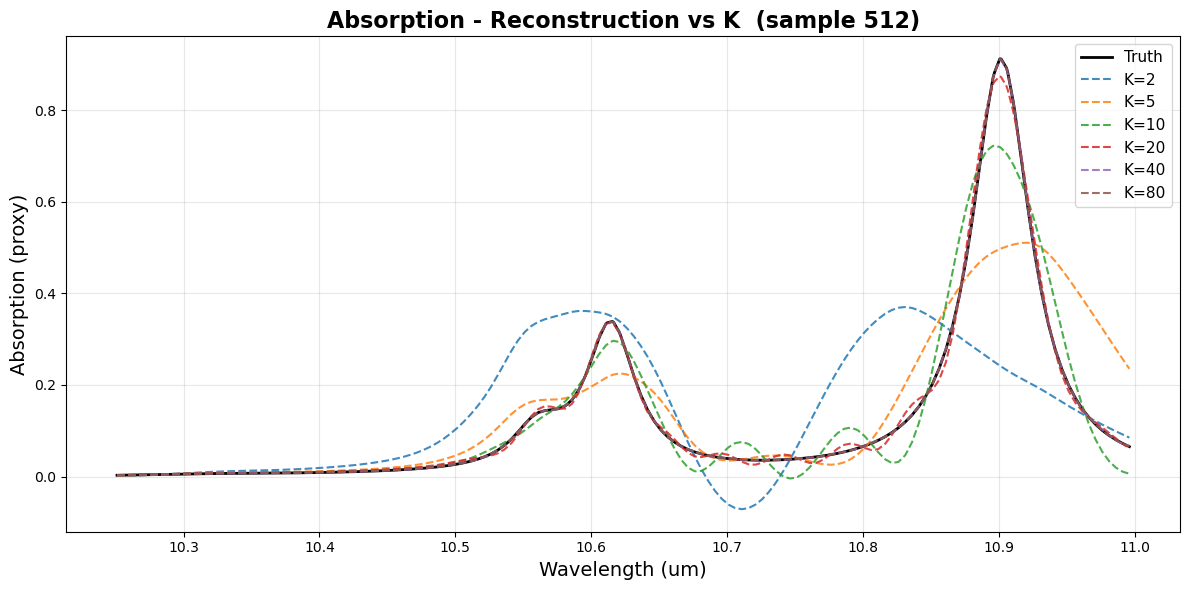

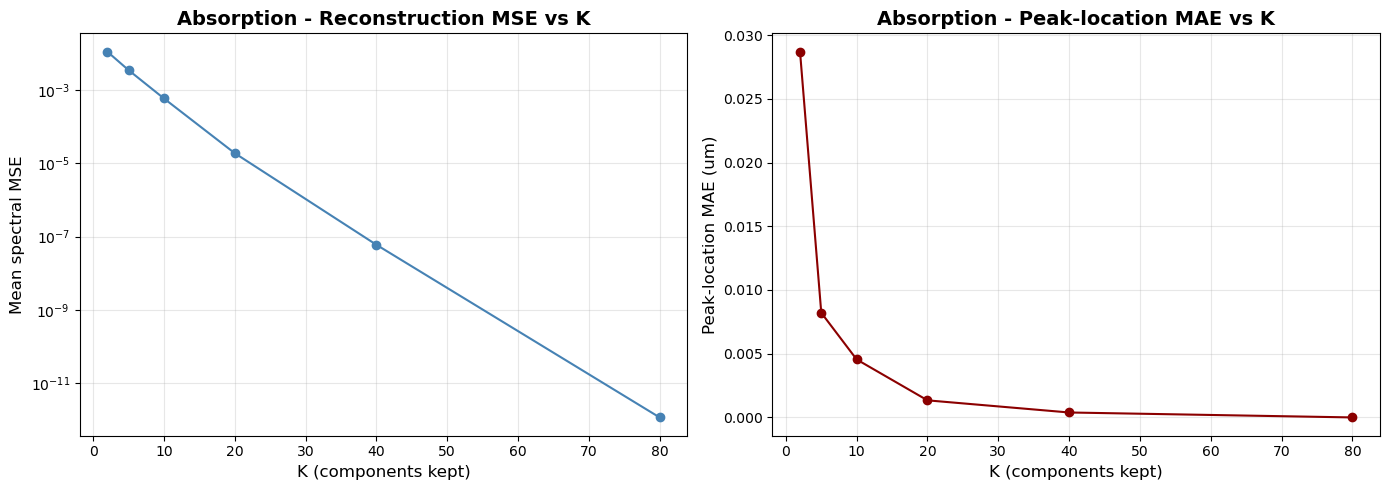

Absorption K-sweep:
  K=  2  MSE=1.123e-02  peak-MAE=0.0287 um
  K=  5  MSE=3.515e-03  peak-MAE=0.0082 um
  K= 10  MSE=5.921e-04  peak-MAE=0.0045 um
  K= 20  MSE=1.898e-05  peak-MAE=0.0013 um
  K= 40  MSE=5.999e-08  peak-MAE=0.0004 um
  K= 80  MSE=1.160e-12  peak-MAE=0.0000 um


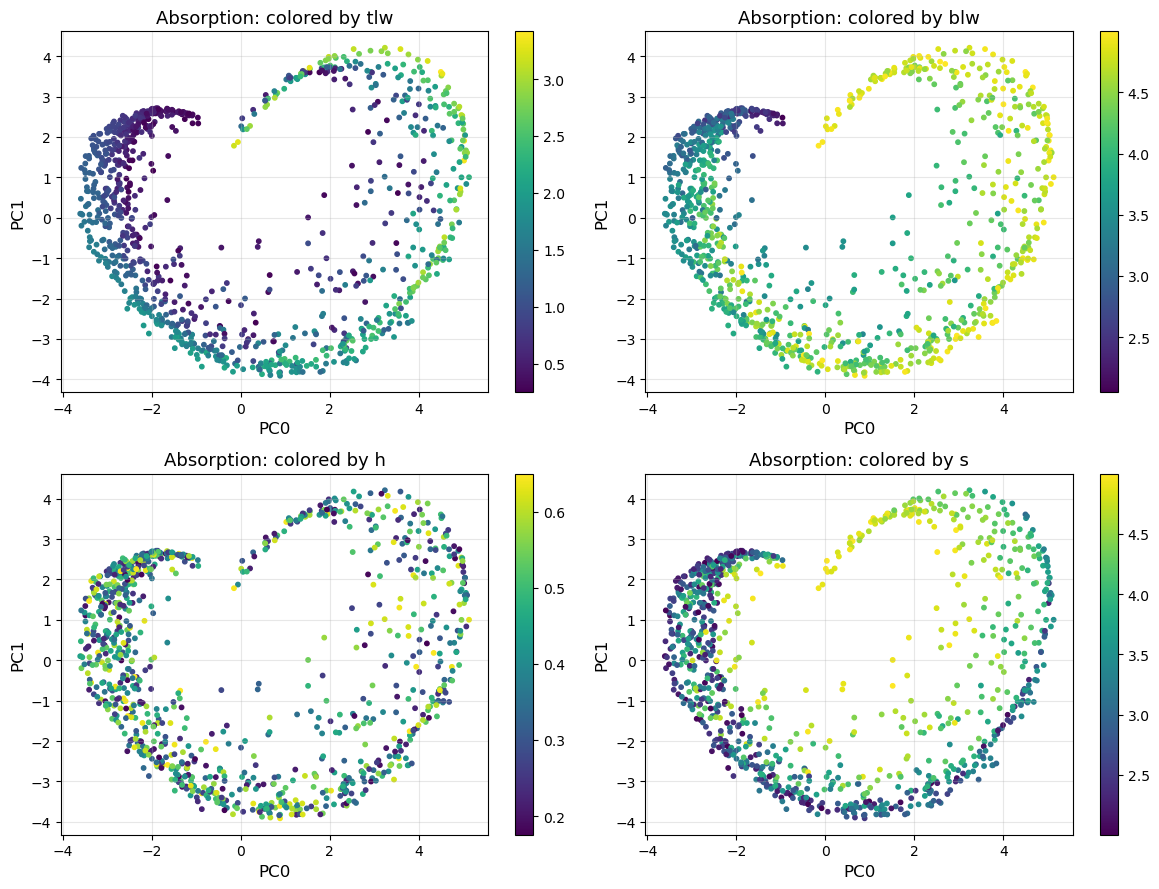

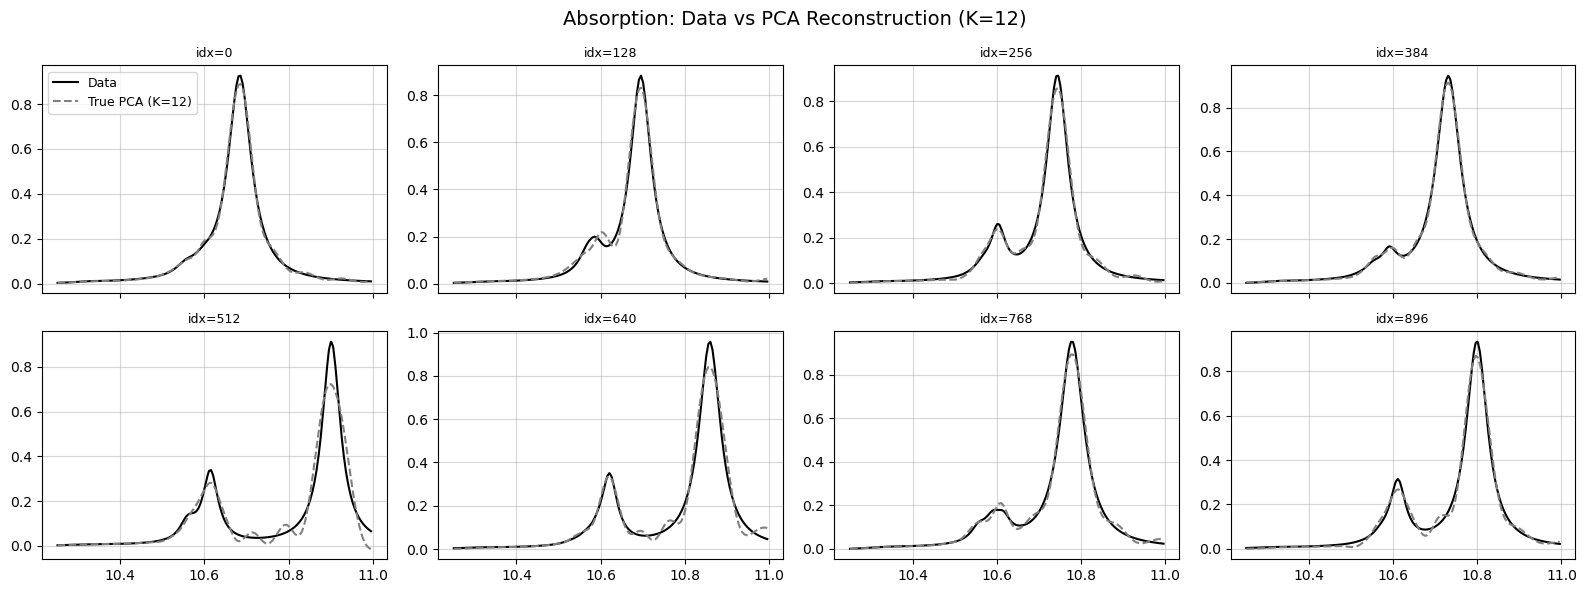

In [ ]:
#### DATA PREPROCESSING PIPELINE - PCA FEATURES (8D GEOMETRY) ####
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
TEST_IDX = np.arange(0, 1024, 128)
INTERP = 4
K = 12
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Print Data and geometry Table for inspection
print(f'\ngeometry labels (4D):\n{geom_labels}\n')
print(f'geometry_table (4D):\n{geom_table.head()}\n')
# print(f'absorption data:\n{abs_data.head()}\n')
# print(f'absorption background:\n{abs_bg.head()}\n')

# Build and fit preprocessing pipelines
abs_pipe  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)
abs_ft_pca  = abs_pipe.fit_transform(abs_data)
abs_pca  = abs_pipe.named_steps['pca'].artifacts_

# Processed spectra (all steps except PCA) — used by exploration plots below
abs_data  = abs_pipe[:-1].fit_transform(abs_data)
wl = abs_data.columns.to_numpy(dtype=float)

# Print feature table for inspection
print(f'Feature table (abs):\n{abs_ft_pca.head()}\n')


#### EXPLORATION PLOTS ####
# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=20)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 8).
plot_latent_colored_by_geom(abs_ft_pca, geom_table, geom_labels, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


#### DATA EXPORT ####
# Create export dict (same format as pca_4D.py; geometry_table is now 8D)
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_features": abs_ft_pca,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels,
    "geometry_table": geom_table,
    "K": K,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "K": K,
    "geometry_dim": 8,
    "derived_features": ["width_sum", "width_diff", "aspect_ratio", "fill_factor"],
}
